# Predicción del precio de HCH — Fase 4 (Analítica 2.0)

Responde los análisis **3.a** (forecast 12-18 meses con intervalo de confianza) y
**3.b** (¿qué variables explican el precio de HCH?) del cuadro de negocio.

**Fuente de datos:** vista `variables_modelo_mensual` (Fase 2) — ya pivotea
HCH (BMC) + 10 indicadores macro/oferta/demanda a una fila por mes.

**Orden de trabajo** (acordado antes de empezar):
1. Duplicados
2. Nulos
3. Feature engineering
4. Multicolinealidad (VIF)
5. Outliers en el target
6. Selección de predictores (importancia de árbol de ensamble)
7. Split walk-forward (TimeSeriesSplit — nunca shuffle aleatorio, es serie de tiempo)
8. Tuning de hiperparámetros con Optuna
9. Entrenar XGBoost + Random Forest (benchmark)
10. Evaluar (RMSE / MAE / MAPE)
11. SHAP sobre el modelo ganador → responde 3.b
12. Forecast + intervalo de confianza → responde 3.a

## 0. Setup

In [3]:
!pip install xgboost optuna shap statsmodels --quiet

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

DB_PATH = "mercado_hch.db"

def q(sql, params=None):
    with sqlite3.connect(DB_PATH) as con:
        return pd.read_sql(sql, con, params=params)

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

print("✅ Librerías cargadas")


✅ Librerías cargadas


## 1. Carga de `variables_modelo_mensual`

In [5]:
df = q("SELECT * FROM variables_modelo_mensual ORDER BY anio, mes")
df['fecha'] = pd.to_datetime(df['anio_mes'] + '-01')

print(f"Total de meses en la vista: {len(df)}")
print(f"Rango: {df['fecha'].min().date()} → {df['fecha'].max().date()}")
df.tail(3)


Total de meses en la vista: 223
Rango: 2008-01-01 → 2026-07-01


,anio_mes,anio,mes,precio_hch_usd_ton,precio_hch_cop_ton,trm,cme_soya,cme_maiz,roni,sacrificio_bovino,demanda_porcina,demanda_concentrado_avicola,demanda_concentrado_porcino,demanda_concentrado_perros,demanda_concentrado_gatos,fecha
220,2026-05,2026,5,446.468571,1.875171e+06,3714.020968,363.172500,181.636000,0.47,NaN,NaN,45291465.45,33041624.92,16671172.06,5626617.66,2026-05-01
221,2026-06,2026,6,NaN,NaN,3500.983000,338.471429,164.567619,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-06-01
222,2026-07,2026,7,NaN,NaN,3275.825517,353.164737,174.839474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2026-07-01


### 1b. Enriquecer con precios de sustitutos (BMC)
`variables_modelo_mensual` se diseñó a propósito "solo HCH" (decisión de Fase 2,
para mantener la vista enfocada en su propósito). Pero los precios de los
sustitutos SÍ predicen bien el precio de HCH — en el notebook de referencia,
`torta_soya_importada` y `ratio_hch_sangre` eran de las variables más
importantes en SHAP. En vez de reabrir el diseño de la vista, los traemos
aquí con una consulta directa a `HechosPrecioInsumo` (que sí los tiene).

In [7]:
SUSTITUTOS = ['torta_soya_importada', 'harina_visceras', 'harina_pluma_sangre',
              'harina_sangre', 'harina_hueso', 'sebo_res', 'subproductos_carnicos',
              'concentrado_aves']

placeholders = ",".join("?" * len(SUSTITUTOS))
df_sust = q(f"""
    SELECT f.anio, f.mes, i.codigo_insumo AS producto,
           AVG(h.precio_cop_ton) AS precio_cop_ton
    FROM HechosPrecioInsumo h
    JOIN DimFecha  f ON h.id_fecha  = f.id_fecha
    JOIN DimInsumo i ON h.id_insumo = i.id_insumo
    JOIN DimFuente fu ON h.id_fuente = fu.id_fuente
    WHERE i.codigo_insumo IN ({placeholders}) AND fu.nombre_fuente = 'BMC'
    GROUP BY f.anio, f.mes, i.codigo_insumo
""", SUSTITUTOS)

df_sust_pivot = df_sust.pivot(index=['anio','mes'], columns='producto', values='precio_cop_ton').reset_index()
df_sust_pivot.columns.name = None

print(f"Sustitutos encontrados en BMC: {[c for c in df_sust_pivot.columns if c not in ('anio','mes')]}")
print(f"Meses con datos de sustitutos: {len(df_sust_pivot)}")

df = df.merge(df_sust_pivot, on=['anio', 'mes'], how='left')
print(f"\nDataset enriquecido: {df.shape[0]} filas × {df.shape[1]} columnas")


Sustitutos encontrados en BMC: ['concentrado_aves', 'harina_hueso', 'harina_pluma_sangre', 'harina_sangre', 'harina_visceras', 'sebo_res', 'subproductos_carnicos', 'torta_soya_importada']
Meses con datos de sustitutos: 45

Dataset enriquecido: 223 filas × 24 columnas


## 2. Duplicados

In [9]:
dups_anio_mes = df['anio_mes'].duplicated().sum()
print(f"anio_mes duplicados: {dups_anio_mes}")

dups_completos = df.duplicated().sum()
print(f"Filas 100% duplicadas: {dups_completos}")

if dups_anio_mes == 0 and dups_completos == 0:
    print("✅ Sin duplicados — la vista ya agrega correctamente por mes (GROUP BY anio, mes)")
else:
    df = df.drop_duplicates(subset=['anio_mes'], keep='first').reset_index(drop=True)
    print("⚠️  Duplicados eliminados")


anio_mes duplicados: 0
Filas 100% duplicadas: 0
✅ Sin duplicados — la vista ya agrega correctamente por mes (GROUP BY anio, mes)


## 3. Nulos
Nos quedamos con la **ventana útil**: meses donde `precio_hch_usd_ton` existe
(2022-09 en adelante). Dentro de esa ventana, `sacrificio_bovino` y
`demanda_porcina` tienen ~4.4% de nulos por el rezago de publicación de
DANE-ESAG (documentado en Fase 2) — se imputan con el promedio histórico
del mismo mes en años anteriores, igual que se hizo en el notebook de
referencia del proyecto.

In [11]:
df_util = df.dropna(subset=['precio_hch_usd_ton']).reset_index(drop=True)
print(f"Ventana útil: {len(df_util)} meses ({df_util['anio_mes'].min()} → {df_util['anio_mes'].max()})")

nulos_antes = df_util.isnull().sum()
print("\nNulos por columna (antes de imputar):")
print(nulos_antes[nulos_antes > 0].to_string())

# Imputación: promedio histórico del mismo mes (estacional), no un promedio plano
cols_a_imputar = nulos_antes[nulos_antes > 0].index.tolist()
for col in cols_a_imputar:
    for idx in df_util[df_util[col].isna()].index:
        mes_i = df_util.loc[idx, 'mes']
        promedio_mes = df_util[(df_util['mes'] == mes_i) & (df_util[col].notna())][col].mean()
        df_util.loc[idx, col] = promedio_mes

nulos_despues = df_util.isnull().sum()
nulos_despues = nulos_despues[nulos_despues > 0]
if len(nulos_despues) == 0:
    print("\n✅ Sin nulos tras imputar")
else:
    print("\n⚠️ Nulos restantes:")
    print(nulos_despues.to_string())


Ventana útil: 45 meses (2022-09 → 2026-05)

Nulos por columna (antes de imputar):
sacrificio_bovino    2
demanda_porcina      2
harina_visceras      3

✅ Sin nulos tras imputar


## 4. Feature engineering
Todas las medias móviles y momentum usan `shift(1)` para no filtrar
información del mes actual (data leakage). Target: `precio_hch_cop_kg`.

In [13]:
df_feat = df_util.copy()
df_feat['precio_hch_cop_kg'] = df_feat['precio_hch_cop_ton'] / 1000

TARGET = 'precio_hch_cop_kg'

# ── Estacionalidad cíclica ────────────────────────────────────────
df_feat['mes_sin'] = np.sin(2 * np.pi * df_feat['mes'] / 12)
df_feat['mes_cos'] = np.cos(2 * np.pi * df_feat['mes'] / 12)
df_feat['trim']    = df_feat['fecha'].dt.quarter

# ── Tendencia secular ──────────────────────────────────────────────
df_feat['t'] = np.arange(len(df_feat))

# ── Lags del target ────────────────────────────────────────────────
for lag in [1, 2, 3, 6]:
    df_feat[f'lag_{lag}'] = df_feat[TARGET].shift(lag)

# ── Medias móviles (shift(1): solo con info del pasado) ────────────
df_feat['ma3']  = df_feat[TARGET].shift(1).rolling(3,  min_periods=1).mean()
df_feat['ma6']  = df_feat[TARGET].shift(1).rolling(6,  min_periods=3).mean()
df_feat['ma12'] = df_feat[TARGET].shift(1).rolling(12, min_periods=6).mean()

# ── Momentum ────────────────────────────────────────────────────────
df_feat['mom1'] = df_feat[TARGET].shift(1) - df_feat[TARGET].shift(2)
df_feat['mom3'] = df_feat[TARGET].shift(1) - df_feat[TARGET].shift(4)

# ── Macro: TRM rezagada y variación ─────────────────────────────────
df_feat['trm_lag1'] = df_feat['trm'].shift(1)
df_feat['trm_diff'] = df_feat['trm'] - df_feat['trm'].shift(1)

# ── RONI con rezago (el fenómeno climático impacta con 3-6 meses) ──
df_feat['roni_lag3'] = df_feat['roni'].shift(3)
df_feat['roni_lag6'] = df_feat['roni'].shift(6)

# ── Ratios de valor relativo HCH vs. commodities Chicago ────────────
df_feat['ratio_hch_soya'] = df_feat['lag_1'] / (df_feat['cme_soya'] / (df_feat['trm'] / 1000)).replace(0, np.nan)
df_feat['ratio_hch_maiz'] = df_feat['lag_1'] / (df_feat['cme_maiz'] / (df_feat['trm'] / 1000)).replace(0, np.nan)

# ── Ratios de valor relativo HCH vs. sustitutos BMC (señal fuerte
# según el notebook de referencia: ratio_hch_sangre fue top-3 en SHAP) ─
SUSTITUTOS_COL = [c for c in SUSTITUTOS if c in df_feat.columns]
for s in SUSTITUTOS_COL:
    df_feat[f'sustituto_{s}_cop_kg'] = df_feat[s] / 1000  # ton -> kg, mismas unidades que el target
    df_feat[f'ratio_hch_{s}'] = df_feat['lag_1'] / df_feat[f'sustituto_{s}_cop_kg'].replace(0, np.nan)

print(f"Features construidas: {len(df_feat.columns)} columnas")
nulos = df_feat.isnull().sum()
print("\nNulos por columna (esperados solo en primeras filas por lags):")
print(nulos[nulos > 0].to_string())


Features construidas: 60 columnas

Nulos por columna (esperados solo en primeras filas por lags):
lag_1                              1
lag_2                              2
lag_3                              3
lag_6                              6
ma3                                1
ma6                                3
ma12                               6
mom1                               2
mom3                               4
trm_lag1                           1
trm_diff                           1
roni_lag3                          3
roni_lag6                          6
ratio_hch_soya                     1
ratio_hch_maiz                     1
ratio_hch_torta_soya_importada     1
ratio_hch_harina_visceras          1
ratio_hch_harina_pluma_sangre      1
ratio_hch_harina_sangre            1
ratio_hch_harina_hueso             1
ratio_hch_sebo_res                 1
ratio_hch_subproductos_carnicos    1
ratio_hch_concentrado_aves         1


## 5. Multicolinealidad (VIF)
Para *predecir*, a los árboles de ensamble casi no les afecta. Pero para
*interpretar* con SHAP (análisis 3.b) sí importa: variables muy
correlacionadas se "roban" importancia entre sí. VIF > 10 es la señal de
alerta estándar.

**Nota técnica:** con ~40 candidatas y solo ~35-40 meses disponibles (los
lags largos como `lag_6`/`roni_lag6`/`ma12` recortan filas), `p` queda muy
cerca de `n` y el cálculo de VIF se vuelve numéricamente inestable si se
corre de una sola vez (salen `inf`). La solución estándar es **eliminación
iterativa**: en cada ronda se calcula VIF de todas las candidatas vivas, se
bota la de VIF más alto, y se repite hasta que todas queden ≤10 (o hasta un
piso mínimo de variables, para no destruir el set).

**`lag_1` queda protegida de esta poda** (correlacionada con `ma3`/`ma6`/
`lag_2` *por construcción*, pero es el ancla autorregresiva del modelo — sin
ella se pierde la señal más fuerte de una serie de precios).

**`t` (contador de tendencia) se excluyó por completo del set de
candidatas**, no solo de la poda VIF. Los árboles de decisión no pueden
extrapolar una variable numérica más allá del rango visto en entrenamiento
— en el forecast de 12-18 meses (sección 13), `t` superaría siempre ese
rango, y el modelo repetiría el valor de la última hoja en vez de seguir
una tendencia real. La dinámica temporal se captura de forma más segura a
través de `lag_1`/`mom1`/`mom3`, que sí se actualizan con cada paso del
forecast recursivo.

In [15]:
CANDIDATOS = [
    'lag_1', 'lag_2', 'lag_3', 'lag_6',
    'ma3', 'ma6', 'ma12', 'mom1', 'mom3',
    'mes_sin', 'mes_cos', 'trim',
    'trm', 'trm_lag1', 'trm_diff',
    'cme_soya', 'cme_maiz',
    'roni', 'roni_lag3', 'roni_lag6',
    'sacrificio_bovino', 'demanda_porcina',
    'demanda_concentrado_avicola', 'demanda_concentrado_porcino',
    'demanda_concentrado_perros', 'demanda_concentrado_gatos',
    'ratio_hch_soya', 'ratio_hch_maiz',
]
for s in SUSTITUTOS_COL:
    CANDIDATOS += [f'sustituto_{s}_cop_kg', f'ratio_hch_{s}']
CANDIDATOS = [c for c in CANDIDATOS if c in df_feat.columns]

df_vif_full = df_feat[[TARGET] + CANDIDATOS].dropna()
print(f"Filas disponibles: {len(df_vif_full)}  |  Candidatas iniciales: {len(CANDIDATOS)}  "
      f"(p/n = {len(CANDIDATOS)/len(df_vif_full):.2f} — ideal < 0.3)")

PROTEGIDAS_VIF = ['lag_1']

def eliminacion_iterativa_vif(df, candidatos, umbral=10.0, min_features=8, protegidas=None):
    protegidas = set(protegidas or [])
    cols = list(candidatos)
    eliminadas = []
    while len(cols) > min_features:
        X = sm.add_constant(df[cols])
        vifs_con_const = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
        vifs = vifs_con_const[1:]  # descartar el VIF de la constante (índice 0)

        elegibles = [i for i, c in enumerate(cols) if c not in protegidas]
        if not elegibles:
            break
        vifs_elegibles = [vifs[i] for i in elegibles]
        max_vif = max(vifs_elegibles)
        if max_vif <= umbral:
            break
        idx_local = elegibles[int(np.argmax(vifs_elegibles))]
        eliminadas.append((cols[idx_local], max_vif))
        cols.pop(idx_local)
    return cols, eliminadas

CANDIDATOS_VIF, eliminadas = eliminacion_iterativa_vif(
    df_vif_full, CANDIDATOS, umbral=10.0, min_features=8, protegidas=PROTEGIDAS_VIF)

print(f"\nProtegidas de la poda (nunca se eliminan): {PROTEGIDAS_VIF}")
print(f"\nEliminadas por VIF alto ({len(eliminadas)} rondas):")
for feat, vif_val in eliminadas:
    vif_str = "inf" if not np.isfinite(vif_val) else f"{vif_val:.1f}"
    print(f"  {feat}  (VIF={vif_str})")

print(f"\nCandidatas restantes: {len(CANDIDATOS_VIF)}  (p/n = {len(CANDIDATOS_VIF)/len(df_vif_full):.2f})")


Filas disponibles: 39  |  Candidatas iniciales: 44  (p/n = 1.13 — ideal < 0.3)

Protegidas de la poda (nunca se eliminan): ['lag_1']

Eliminadas por VIF alto (24 rondas):
  lag_2  (VIF=inf)
  lag_3  (VIF=inf)
  trm  (VIF=inf)
  ma12  (VIF=9007199254740992.0)
  sustituto_harina_pluma_sangre_cop_kg  (VIF=428914250225761.5)
  ma3  (VIF=inf)
  ratio_hch_harina_sangre  (VIF=43820.5)
  ratio_hch_concentrado_aves  (VIF=26297.3)
  sustituto_harina_hueso_cop_kg  (VIF=16366.8)
  ratio_hch_sebo_res  (VIF=7299.1)
  ma6  (VIF=4715.5)
  ratio_hch_maiz  (VIF=3780.3)
  ratio_hch_harina_visceras  (VIF=2451.5)
  cme_soya  (VIF=1668.9)
  sustituto_torta_soya_importada_cop_kg  (VIF=1380.8)
  sustituto_subproductos_carnicos_cop_kg  (VIF=220.5)
  sustituto_concentrado_aves_cop_kg  (VIF=194.2)
  roni  (VIF=87.7)
  lag_6  (VIF=50.6)
  trm_lag1  (VIF=40.8)
  roni_lag6  (VIF=26.9)
  cme_maiz  (VIF=22.9)
  demanda_concentrado_perros  (VIF=19.3)
  demanda_porcina  (VIF=13.7)

Candidatas restantes: 20  (p/n = 0.51

### 5.1 VIF final (sobre el set ya depurado)

In [17]:
df_vif_base = df_feat[CANDIDATOS_VIF].dropna()
X_vif_final = sm.add_constant(df_vif_base)

vif_data = pd.DataFrame()
vif_data['feature'] = CANDIDATOS_VIF
vif_data['VIF'] = [variance_inflation_factor(X_vif_final.values, i+1) for i in range(len(CANDIDATOS_VIF))]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)

print("VIF final por feature:")
print(vif_data.to_string(index=False))

alerta_vif = vif_data[vif_data['VIF'] > 10]['feature'].tolist()
if alerta_vif:
    print(f"\n⚠️  Aún por encima de 10 (se llegó al piso mínimo de variables): {alerta_vif}")
else:
    print("\n✅ Todas las features quedaron con VIF ≤ 10")

# CANDIDATOS apunta ahora al set depurado, para las secciones siguientes
CANDIDATOS = CANDIDATOS_VIF


VIF final por feature:
                         feature       VIF
                           lag_1 22.370548
     demanda_concentrado_avicola  9.229049
                            trim  9.208994
       sustituto_sebo_res_cop_kg  7.710679
   ratio_hch_harina_pluma_sangre  7.541378
                         mes_sin  6.851170
  sustituto_harina_sangre_cop_kg  6.141416
                  ratio_hch_soya  5.772996
     demanda_concentrado_porcino  5.435904
          ratio_hch_harina_hueso  5.219235
                            mom3  5.095563
       demanda_concentrado_gatos  4.643017
                       roni_lag3  4.556583
sustituto_harina_visceras_cop_kg  4.011052
               sacrificio_bovino  3.981468
 ratio_hch_subproductos_carnicos  3.184198
                         mes_cos  2.787211
                            mom1  2.779283
  ratio_hch_torta_soya_importada  2.773567
                        trm_diff  1.773638

⚠️  Aún por encima de 10 (se llegó al piso mínimo de variables): ['lag_1'

## 6. Outliers en el target
Dos chequeos complementarios: **IQR** sobre la distribución del target, y
**Distancia de Cook** sobre un ajuste OLS con todas las candidatas — mide
qué tan influyente es cada mes sobre el ajuste (no solo si el valor en sí
es extremo, sino si "jala" el modelo de forma desproporcionada).

Límites IQR: [582, 4073] COP/kg
Outliers IQR en precio_hch_cop_kg: 0
✅ Sin outliers IQR (consistente con el filtro ya aplicado en Fase 1)


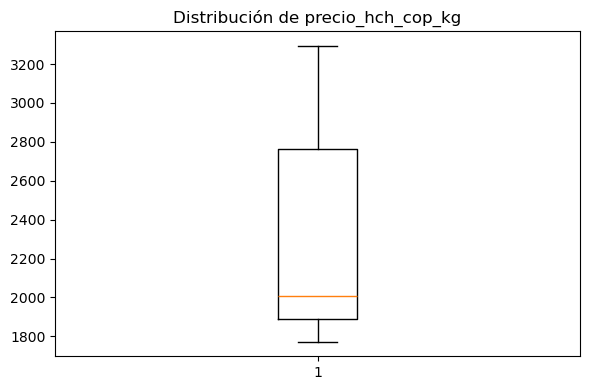

In [19]:
q1, q3 = df_feat[TARGET].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers_iqr = df_feat[(df_feat[TARGET] < lim_inf) | (df_feat[TARGET] > lim_sup)]

print(f"Límites IQR: [{lim_inf:.0f}, {lim_sup:.0f}] COP/kg")
print(f"Outliers IQR en {TARGET}: {len(outliers_iqr)}")
if len(outliers_iqr):
    print(outliers_iqr[['anio_mes', TARGET]].to_string(index=False))
else:
    print("✅ Sin outliers IQR (consistente con el filtro ya aplicado en Fase 1)")

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(df_feat[TARGET].dropna(), vert=True)
ax.set_title(f'Distribución de {TARGET}')
plt.tight_layout()
plt.show()


### 6.1 Distancia de Cook (influencia sobre el ajuste OLS)

Umbral (4/n): 0.0976
Meses influyentes (Cook's D > umbral): 5 de 41
anio_mes  precio_hch_cop_kg  cooks_d
 2023-01        3165.506429 0.543752
 2023-10        2763.774118 0.517866
 2023-09        2633.878824 0.325437
 2024-10        2042.718095 0.296864
 2023-05        3280.953889 0.140616


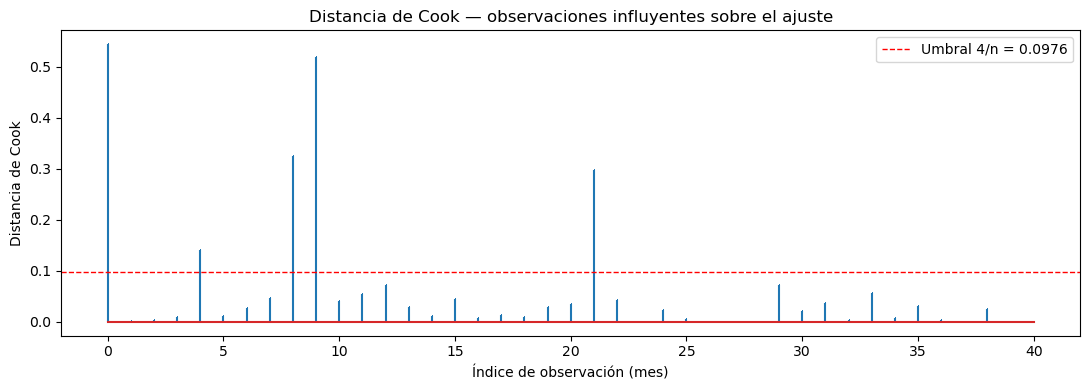


⚠️  Revisar estos 5 meses: ¿evento real (choque de precio) o dato mal capturado?


In [21]:
df_cook = df_feat[[TARGET] + CANDIDATOS].dropna().reset_index(drop=False)
X_cook = sm.add_constant(df_cook[CANDIDATOS])
y_cook = df_cook[TARGET]

modelo_ols = sm.OLS(y_cook, X_cook).fit()
influencia = OLSInfluence(modelo_ols)
cooks_d = influencia.cooks_distance[0]

umbral = 4 / len(df_cook)  # regla práctica estándar: 4/n
df_cook['cooks_d'] = cooks_d
df_cook['anio_mes'] = df_feat.loc[df_cook['index'], 'anio_mes'].values

influyentes = df_cook[df_cook['cooks_d'] > umbral].sort_values('cooks_d', ascending=False)

print(f"Umbral (4/n): {umbral:.4f}")
print(f"Meses influyentes (Cook's D > umbral): {len(influyentes)} de {len(df_cook)}")
if len(influyentes):
    print(influyentes[['anio_mes', TARGET, 'cooks_d']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
ax.stem(range(len(cooks_d)), cooks_d, markerfmt=',')
ax.axhline(umbral, color='red', linestyle='--', linewidth=1, label=f'Umbral 4/n = {umbral:.4f}')
ax.set_xlabel('Índice de observación (mes)')
ax.set_ylabel("Distancia de Cook")
ax.set_title("Distancia de Cook — observaciones influyentes sobre el ajuste")
ax.legend()
plt.tight_layout()
plt.show()

if len(influyentes) == 0:
    print("\n✅ Ninguna observación supera el umbral — no hay meses desproporcionadamente influyentes")
else:
    print(f"\n⚠️  Revisar estos {len(influyentes)} meses: ¿evento real (choque de precio) o dato mal capturado?")


In [58]:
MESES_COOK = ['2023-01', '2023-10', '2023-09', '2024-10', '2023-05']

for mes_objetivo in MESES_COOK:
    idx = df_feat[df_feat['anio_mes'] == mes_objetivo].index[0]
    ventana = df_feat.loc[max(0, idx-2):idx+2, ['anio_mes', TARGET, 'trm', 'cme_soya', 'cme_maiz', 'roni']].copy()
    ventana['var_precio_%'] = ventana[TARGET].pct_change() * 100
    ventana['var_trm_%']    = ventana['trm'].pct_change() * 100
    ventana['var_soya_%']   = ventana['cme_soya'].pct_change() * 100
    ventana['var_maiz_%']   = ventana['cme_maiz'].pct_change() * 100

    print(f"\n{'='*70}\n{mes_objetivo}\n{'='*70}")
    print(ventana.round(2).to_string(index=False))


2023-01
anio_mes  precio_hch_cop_kg     trm  cme_soya  cme_maiz  roni  var_precio_%  var_trm_%  var_soya_%  var_maiz_%
 2022-11            2751.73 4926.66    455.01    263.09 -1.05           NaN        NaN         NaN         NaN
 2022-12            3178.35 4788.49    500.13    256.24 -0.97         15.50      -2.80        9.92       -2.60
 2023-01            3165.51 4715.20    533.77    263.93 -0.83         -0.40      -1.53        6.73        3.00
 2023-02            3203.18 4803.11    543.36    264.21 -0.62          1.19       1.86        1.80        0.10
 2023-03            3292.35 4766.31    523.95    250.94 -0.44          2.78      -0.77       -3.57       -5.02

2023-10
anio_mes  precio_hch_cop_kg     trm  cme_soya  cme_maiz  roni  var_precio_%  var_trm_%  var_soya_%  var_maiz_%
 2023-08            3170.11 4070.73    470.20    187.34  0.85           NaN        NaN         NaN         NaN
 2023-09            2633.88 4004.52    438.66    186.53  1.10        -16.92      -1.63       -

## 7. Selección de predictores (árbol de ensamble)
Random Forest rápido sobre todos los candidatos → importancia por
`feature_importances_`, confirmada con permutation importance. Nos
quedamos con el top de variables que realmente aportan.

In [23]:
df_sel = df_feat.dropna(subset=[TARGET] + CANDIDATOS).copy()
print(f"Filas disponibles tras dropna de candidatos: {len(df_sel)}")

X_sel = df_sel[CANDIDATOS].values
y_sel = df_sel[TARGET].values

rf_sel = RandomForestRegressor(n_estimators=300, max_depth=4, random_state=42)
rf_sel.fit(X_sel, y_sel)

imp_gain = pd.Series(rf_sel.feature_importances_, index=CANDIDATOS).sort_values(ascending=False)

perm = permutation_importance(rf_sel, X_sel, y_sel, n_repeats=30, random_state=42, scoring='neg_mean_absolute_error')
imp_perm = pd.Series(np.abs(perm.importances_mean), index=CANDIDATOS).sort_values(ascending=False)

resumen_sel = pd.DataFrame({'gain_rf': imp_gain, 'permutation': imp_perm}).fillna(0)
resumen_sel['score'] = resumen_sel['gain_rf'].rank(ascending=False) + resumen_sel['permutation'].rank(ascending=False)
resumen_sel = resumen_sel.sort_values('score')

print("Ranking combinado (menor score = más importante):")
print(resumen_sel.round(4).to_string())


Filas disponibles tras dropna de candidatos: 41
Ranking combinado (menor score = más importante):
                                  gain_rf  permutation  score
lag_1                              0.3512     168.6003    2.0
sustituto_sebo_res_cop_kg          0.2264      85.4616    4.0
sustituto_harina_visceras_cop_kg   0.1288      47.6480    6.0
ratio_hch_harina_pluma_sangre      0.1166      44.7318    8.0
roni_lag3                          0.0361      34.6841   12.0
sustituto_harina_sangre_cop_kg     0.0579      16.5560   12.0
ratio_hch_soya                     0.0452      17.0410   12.0
mom3                               0.0077       7.0170   16.0
ratio_hch_harina_hueso             0.0070       4.3361   18.0
mom1                               0.0040       2.7427   21.0
ratio_hch_torta_soya_importada     0.0025       1.4075   25.0
demanda_concentrado_avicola        0.0015       1.4089   27.0
ratio_hch_subproductos_carnicos    0.0015       2.1778   27.0
demanda_concentrado_gatos         

### 7.1 Búsqueda del número óptimo de features (N)
En vez de fijar un número arbitrario (ej. copiar el 12 que funcionó en otro
notebook con otro set de candidatas), probamos cada N desde 5 hasta 20,
tomando siempre las top-N del ranking anterior, y medimos el RMSE de CV
walk-forward para cada tamaño. Nos quedamos con el N que minimiza el error
— así el número lo decide este dataset, no una copia de otro proyecto.

 n_features  rmse_cv    std
          5   128.41 102.29
          6   127.43 117.02
          7   127.40  96.46
          8   128.43 121.16
          9   116.71  99.90
         10   118.18 115.21
         11   123.52 105.46
         12   122.70 122.78
         13   126.73 132.24
         14   128.74 120.23
         15   125.66 114.60
         16   127.05 122.48
         17   126.19 103.55
         18   128.46 126.35
         19   111.66  98.50
         20   126.32 116.90

✅ N óptimo (menor RMSE de CV): 19


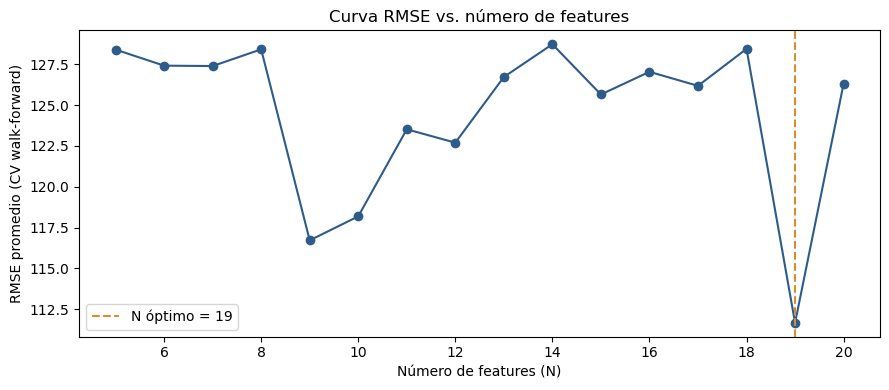


✅ Features seleccionadas (19): ['lag_1', 'sustituto_sebo_res_cop_kg', 'sustituto_harina_visceras_cop_kg', 'ratio_hch_harina_pluma_sangre', 'roni_lag3', 'sustituto_harina_sangre_cop_kg', 'ratio_hch_soya', 'mom3', 'ratio_hch_harina_hueso', 'mom1', 'ratio_hch_torta_soya_importada', 'demanda_concentrado_avicola', 'ratio_hch_subproductos_carnicos', 'demanda_concentrado_gatos', 'mes_sin', 'trm_diff', 'demanda_concentrado_porcino', 'sacrificio_bovino', 'trim']


In [25]:
ranking_ordenado = resumen_sel.index.tolist()
N_MIN, N_MAX = 5, min(20, len(ranking_ordenado))

PARAMS_BUSQUEDA = dict(n_estimators=300, learning_rate=0.05, max_depth=3,
                        subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
                        reg_lambda=5.0, reg_alpha=1.0, random_state=42, verbosity=0)

resultados_n = []
for n in range(N_MIN, N_MAX + 1):
    feats_n = ranking_ordenado[:n]
    df_n = df_feat.dropna(subset=[TARGET] + feats_n)
    X_n, y_n = df_n[feats_n].values, df_n[TARGET].values

    tscv_n = TimeSeriesSplit(n_splits=5, test_size=3)
    rmses_n = []
    for tr_idx, te_idx in tscv_n.split(X_n):
        m = xgb.XGBRegressor(**PARAMS_BUSQUEDA)
        m.fit(X_n[tr_idx], y_n[tr_idx])
        rmses_n.append(rmse(y_n[te_idx], m.predict(X_n[te_idx])))

    resultados_n.append({'n_features': n, 'rmse_cv': np.mean(rmses_n), 'std': np.std(rmses_n)})

df_busqueda_n = pd.DataFrame(resultados_n)
print(df_busqueda_n.round(2).to_string(index=False))

N_OPTIMO = int(df_busqueda_n.loc[df_busqueda_n['rmse_cv'].idxmin(), 'n_features'])
print(f"\n✅ N óptimo (menor RMSE de CV): {N_OPTIMO}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(df_busqueda_n['n_features'], df_busqueda_n['rmse_cv'], marker='o', color='#2E5C8A')
ax.axvline(N_OPTIMO, color='#D98E2B', linestyle='--', label=f'N óptimo = {N_OPTIMO}')
ax.set_xlabel('Número de features (N)')
ax.set_ylabel('RMSE promedio (CV walk-forward)')
ax.set_title('Curva RMSE vs. número de features')
ax.legend()
plt.tight_layout()
plt.show()

FEATURES = ranking_ordenado[:N_OPTIMO]
print(f"\n✅ Features seleccionadas ({len(FEATURES)}): {FEATURES}")


## 8. Split walk-forward (TimeSeriesSplit)

In [27]:
df_clean = df_feat.dropna(subset=[TARGET] + FEATURES).reset_index(drop=True)
print(f"Filas para entrenar: {len(df_clean)} meses ({df_clean['anio_mes'].min()} → {df_clean['anio_mes'].max()})")

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

N_SPLITS = 5
TEST_SIZE = 3
tscv = TimeSeriesSplit(n_splits=N_SPLITS, test_size=TEST_SIZE)

print(f"\nTimeSeriesSplit: {N_SPLITS} folds, test_size={TEST_SIZE} meses (nunca shuffle — es serie de tiempo)")
for fold, (tr_idx, te_idx) in enumerate(tscv.split(X)):
    print(f"  Fold {fold+1}: train={len(tr_idx)} meses | test={df_clean.iloc[te_idx]['anio_mes'].tolist()}")


Filas para entrenar: 41 meses (2023-01 → 2026-05)

TimeSeriesSplit: 5 folds, test_size=3 meses (nunca shuffle — es serie de tiempo)
  Fold 1: train=26 meses | test=['2025-03', '2025-04', '2025-05']
  Fold 2: train=29 meses | test=['2025-06', '2025-07', '2025-08']
  Fold 3: train=32 meses | test=['2025-09', '2025-10', '2025-11']
  Fold 4: train=35 meses | test=['2025-12', '2026-01', '2026-02']
  Fold 5: train=38 meses | test=['2026-03', '2026-04', '2026-05']


## 9. Tuning de hiperparámetros con Optuna
Búsqueda bayesiana minimizando **RMSE** promedio en el CV walk-forward
(RMSE como objetivo de optimización — MAE/MAPE se reportan después como
métricas de negocio, ver sección 10).

In [29]:
def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 600),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 2, 5),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1.0, 20.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.0, 5.0),
        'random_state': 42, 'verbosity': 0,
    }
    rmses = []
    for tr_idx, te_idx in tscv.split(X):
        m = xgb.XGBRegressor(**params)
        m.fit(X[tr_idx], y[tr_idx])
        preds = m.predict(X[te_idx])
        rmses.append(rmse(y[te_idx], preds))
    return np.mean(rmses)

sampler = optuna.samplers.TPESampler(seed=42)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective, n_trials=150, show_progress_bar=True)

print(f"\n✅ Mejor RMSE (CV): {study.best_value:.2f} COP/kg")
print("Mejores parámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

PARAMS_XGB = {**study.best_params, 'random_state': 42, 'verbosity': 0}


  0%|          | 0/150 [00:00<?, ?it/s]


✅ Mejor RMSE (CV): 90.61 COP/kg
Mejores parámetros:
  n_estimators: 551
  learning_rate: 0.0543065788215364
  max_depth: 2
  subsample: 0.5120464460856305
  colsample_bytree: 0.951935756424119
  min_child_weight: 1
  reg_lambda: 2.7697444943048315
  reg_alpha: 1.935564425249228


## 10. Entrenar XGBoost (tuneado) + Random Forest (benchmark)
XGBoost es el modelo principal (maneja NaN nativo, mejor con interacciones
no lineales, soporta regresión cuantílica para el intervalo de confianza).
Random Forest corre como control — si XGBoost se sobreajusta, RF (más
conservador) lo revela por comparación.

In [31]:
def evaluar_cv(modelo_cls, params, X, y, tscv):
    mae_f, rmse_f, mape_f = [], [], []
    for tr_idx, te_idx in tscv.split(X):
        m = modelo_cls(**params)
        m.fit(X[tr_idx], y[tr_idx])
        preds = m.predict(X[te_idx])
        mae_f.append(mean_absolute_error(y[te_idx], preds))
        rmse_f.append(rmse(y[te_idx], preds))
        mape_f.append(mape(y[te_idx], preds))
    return np.mean(mae_f), np.mean(rmse_f), np.mean(mape_f), np.std(mape_f)

# ── XGBoost baseline (sin tunear) para comparar ──────────────────
PARAMS_BASE = dict(n_estimators=300, learning_rate=0.05, max_depth=3,
                    subsample=0.8, colsample_bytree=0.7, min_child_weight=3,
                    reg_lambda=5.0, reg_alpha=1.0, random_state=42, verbosity=0)

mae_b, rmse_b, mape_b, std_b = evaluar_cv(xgb.XGBRegressor, PARAMS_BASE, X, y, tscv)
mae_x, rmse_x, mape_x, std_x = evaluar_cv(xgb.XGBRegressor, PARAMS_XGB, X, y, tscv)

# ── Random Forest benchmark ───────────────────────────────────────
PARAMS_RF = dict(n_estimators=400, max_depth=4, min_samples_leaf=2, random_state=42)
mae_r, rmse_r, mape_r, std_r = evaluar_cv(RandomForestRegressor, PARAMS_RF, X, y, tscv)

comparacion = pd.DataFrame([
    {'Modelo': 'XGBoost baseline',  'MAE (COP/kg)': mae_b, 'RMSE (COP/kg)': rmse_b, 'MAPE (%)': mape_b, 'MAPE std': std_b},
    {'Modelo': 'XGBoost + Optuna',  'MAE (COP/kg)': mae_x, 'RMSE (COP/kg)': rmse_x, 'MAPE (%)': mape_x, 'MAPE std': std_x},
    {'Modelo': 'Random Forest',     'MAE (COP/kg)': mae_r, 'RMSE (COP/kg)': rmse_r, 'MAPE (%)': mape_r, 'MAPE std': std_r},
]).round(2)

print(comparacion.to_string(index=False))

modelo_ganador = comparacion.loc[comparacion['RMSE (COP/kg)'].idxmin(), 'Modelo']
print(f"\n🏆 Mejor modelo (menor RMSE): {modelo_ganador}")


          Modelo  MAE (COP/kg)  RMSE (COP/kg)  MAPE (%)  MAPE std
XGBoost baseline         95.10         111.66      5.12      4.14
XGBoost + Optuna         82.49          90.61      4.42      2.75
   Random Forest        107.48         129.28      5.77      4.18

🏆 Mejor modelo (menor RMSE): XGBoost + Optuna


## 11. Modelo final — entrenado con el 100% de los datos

In [33]:
modelo_final = xgb.XGBRegressor(**PARAMS_XGB)
modelo_final.fit(X, y)

modelo_rf = RandomForestRegressor(**PARAMS_RF)
modelo_rf.fit(X, y)

print("✅ Modelo final XGBoost entrenado con el 100% de los datos")
print(f"   MAE CV  : {mae_x:.0f} COP/kg")
print(f"   RMSE CV : {rmse_x:.0f} COP/kg")
print(f"   MAPE CV : {mape_x:.2f}% ± {std_x:.2f}%")


✅ Modelo final XGBoost entrenado con el 100% de los datos
   MAE CV  : 82 COP/kg
   RMSE CV : 91 COP/kg
   MAPE CV : 4.42% ± 2.75%


## 12. SHAP — Interpretabilidad (responde análisis 3.b)
SHAP mide cuánto contribuye cada variable a cada predicción individual del
modelo ganador. Color rojo = valor alto de esa feature ese mes; posición en
X = cuánto sube (+) o baja (-) la predicción.

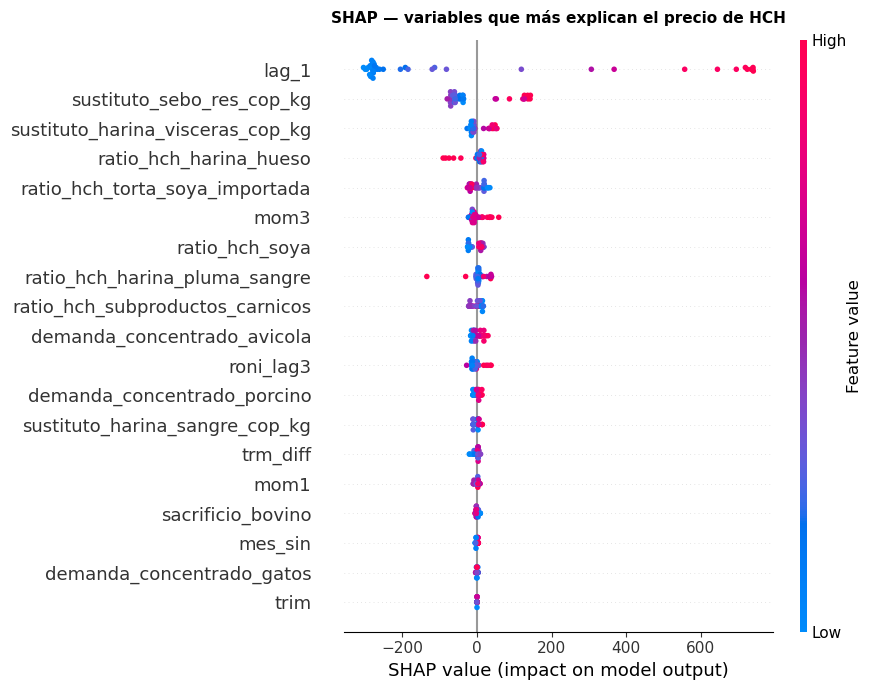


Ranking SHAP (importancia media absoluta):
lag_1                               351.959991
sustituto_sebo_res_cop_kg            72.349998
sustituto_harina_visceras_cop_kg     19.780001
ratio_hch_harina_hueso               17.549999
ratio_hch_torta_soya_importada       16.930000
mom3                                 15.960000
ratio_hch_soya                       14.990000
ratio_hch_harina_pluma_sangre        14.740000
ratio_hch_subproductos_carnicos      12.230000
demanda_concentrado_avicola          11.330000
roni_lag3                            10.550000
demanda_concentrado_porcino           6.150000
sustituto_harina_sangre_cop_kg        5.030000
trm_diff                              4.640000
mom1                                  3.370000
sacrificio_bovino                     3.200000
mes_sin                               2.590000
demanda_concentrado_gatos             1.360000
trim                                  0.290000


In [35]:
import shap

explainer = shap.TreeExplainer(modelo_final)
shap_values = explainer.shap_values(df_clean[FEATURES])

fig, ax = plt.subplots(figsize=(9, 7))
shap.summary_plot(shap_values, df_clean[FEATURES], feature_names=FEATURES, show=False, plot_size=None)
plt.title('SHAP — variables que más explican el precio de HCH', fontsize=11, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

shap_ranking = pd.Series(np.abs(shap_values).mean(axis=0), index=FEATURES).sort_values(ascending=False)
print("\nRanking SHAP (importancia media absoluta):")
print(shap_ranking.round(2).to_string())


## 13. Forecast 12-18 meses con intervalo de confianza (responde análisis 3.a)

**Forecast directo, no recursivo.** La primera versión encadenaba
predicciones (el mes 1 alimentaba el mes 2, ese al mes 3, etc.) — con
árboles de decisión eso "colapsa" rápido en un punto fijo porque una vez
la predicción cae dentro del rango de una misma hoja del árbol, el modelo
empieza a repetir casi el mismo valor (limitación conocida de forecast
recursivo con árboles, no un bug de una celda).

**La solución estándar:** entrenar **un modelo por cada horizonte** h=1,
2, ..., 18 — cada uno aprende a predecir directamente el precio a h meses
en el futuro, usando solo la información disponible *hoy* (sin encadenar
nada). Se predice una sola vez con la última fila conocida, a través de
cada uno de los 18 modelos.

**Limitación explícita:** con solo ~40 meses de historia, los horizontes
largos (h=15-18) entrenan con pocas filas (`shift(-h)` recorta el dataset)
— el intervalo de confianza de esos meses va a ser más ancho y menos
confiable que el de los primeros meses, y es esperable.

In [37]:
N_FORECAST = 18
X_last = df_clean[FEATURES].iloc[[-1]].values  # última fila conocida (hoy)
fecha_base = df_clean['fecha'].iloc[-1]
fechas_fut = pd.date_range(start=fecha_base + pd.DateOffset(months=1), periods=N_FORECAST, freq='MS')

preds_punto, ic_low, ic_high, filas_h, rmse_h_list = [], [], [], [], []
N_BOOT = 1000
ultimo_residuo_confiable = np.array([0.0])  # respaldo si un horizonte no alcanza a estimar el suyo

for h in range(1, N_FORECAST + 1):
    y_h = df_feat[TARGET].shift(-h)
    df_h = df_feat[FEATURES].copy()
    df_h['y_h'] = y_h
    df_h = df_h.dropna()

    if len(df_h) < 12:
        print(f"⚠️  Horizonte h={h}: solo {len(df_h)} filas disponibles, se omite (muy pocos datos)")
        continue

    X_h, y_hv = df_h[FEATURES].values, df_h['y_h'].values

    # CV walk-forward específico de este horizonte (para RMSE y residuos)
    n_splits_h = max(2, min(5, len(df_h) // 8))
    tscv_h = TimeSeriesSplit(n_splits=n_splits_h, test_size=1)
    residuos_h = []
    for tr_idx, te_idx in tscv_h.split(X_h):
        if len(tr_idx) < 8:
            continue
        m = xgb.XGBRegressor(**PARAMS_XGB)
        m.fit(X_h[tr_idx], y_hv[tr_idx])
        residuos_h.extend(y_hv[te_idx] - m.predict(X_h[te_idx]))
    residuos_h = np.array(residuos_h)

    if len(residuos_h) >= 3:
        ultimo_residuo_confiable = residuos_h  # se actualiza el respaldo
    else:
        print(f"   ℹ️  h={h}: pocos residuos propios ({len(residuos_h)}) — usando el IC del horizonte confiable más cercano")
        residuos_h = ultimo_residuo_confiable

    # Modelo final de este horizonte, con el 100% de los datos disponibles para él
    modelo_h = xgb.XGBRegressor(**PARAMS_XGB)
    modelo_h.fit(X_h, y_hv)
    pred_h = modelo_h.predict(X_last)[0]

    # Bootstrap de residuos propios de este horizonte (o del respaldo).
    # Se centran en cero primero: con muestras tan chicas (2-5 residuos), el
    # promedio muestral puede quedar sesgado por azar y correr el intervalo
    # completo hacia un solo lado de la predicción puntual — centrar evita eso.
    residuos_centrados = residuos_h - residuos_h.mean()
    boot_h = pred_h + np.random.choice(residuos_centrados, size=N_BOOT, replace=True)

    p5, p95 = np.percentile(boot_h, [5, 95])
    p5, p95 = min(p5, pred_h), max(p95, pred_h)  # resguardo: el IC siempre contiene el punto

    preds_punto.append(pred_h)
    ic_low.append(p5)
    ic_high.append(p95)
    rmse_h_list.append(rmse(y_hv[te_idx], modelo_h.predict(X_h[te_idx])) if len(residuos_h) > 1 else np.nan)
    filas_h.append(len(df_h))

df_forecast = pd.DataFrame({
    'fecha': fechas_fut[:len(preds_punto)],
    'anio_mes': fechas_fut[:len(preds_punto)].strftime('%Y-%m'),
    'precio_hch_pred': preds_punto, 'ic_5': ic_low, 'ic_95': ic_high,
    'filas_entrenamiento': filas_h,
})
print(df_forecast.round(0).to_string(index=False))


   ℹ️  h=18: pocos residuos propios (2) — usando el IC del horizonte confiable más cercano
     fecha anio_mes  precio_hch_pred   ic_5  ic_95  filas_entrenamiento
2026-06-01  2026-06           1835.0 1770.0 1890.0                   40
2026-07-01  2026-07           1883.0 1863.0 1935.0                   39
2026-08-01  2026-08           1888.0 1831.0 1920.0                   38
2026-09-01  2026-09           1950.0 1895.0 1984.0                   37
2026-10-01  2026-10           1989.0 1915.0 2029.0                   36
2026-11-01  2026-11           1851.0 1819.0 1917.0                   35
2026-12-01  2026-12           1956.0 1914.0 2058.0                   34
2027-01-01  2027-01           1897.0 1849.0 1990.0                   33
2027-02-01  2027-02           1825.0 1767.0 1932.0                   32
2027-03-01  2027-03           1863.0 1823.0 1935.0                   31
2027-04-01  2027-04           1867.0 1741.0 1999.0                   30
2027-05-01  2027-05           1892.0 1793.0 2

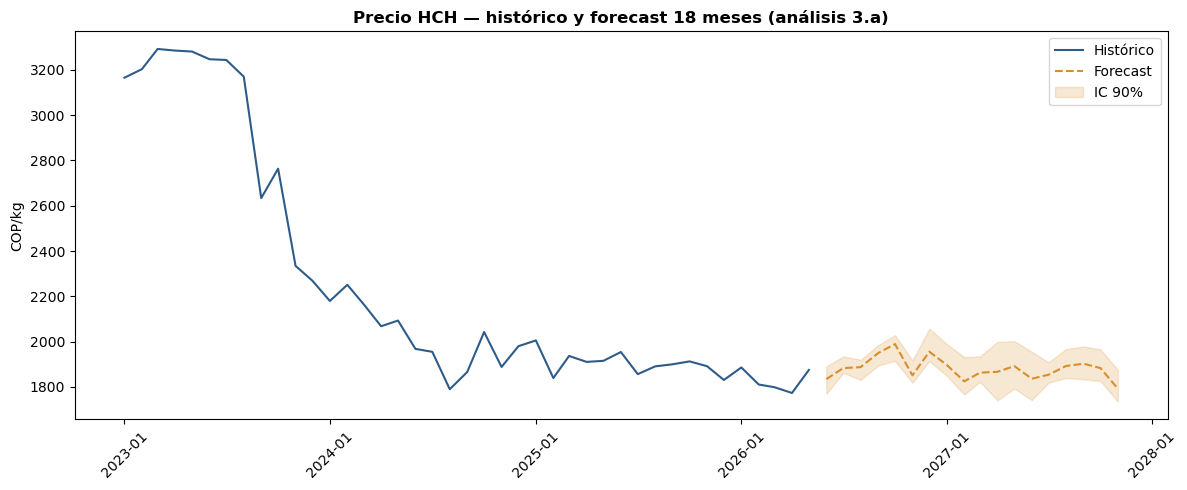

In [38]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_clean['fecha'], df_clean[TARGET], color='#2E5C8A', label='Histórico', linewidth=1.5)
ax.plot(df_forecast['fecha'], df_forecast['precio_hch_pred'], color='#D98E2B', label='Forecast', linewidth=1.5, linestyle='--')
ax.fill_between(df_forecast['fecha'], df_forecast['ic_5'], df_forecast['ic_95'],
                 color='#D98E2B', alpha=0.2, label='IC 90%')
ax.set_title('Precio HCH — histórico y forecast 18 meses (análisis 3.a)', fontsize=12, fontweight='bold')
ax.set_ylabel('COP/kg')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
